# Digital Options: Interactive Analysis & Visualizations

**Product Type:** European Digital (Binary) Option  
**Purpose:** Interactive exploration of digital option pricing, Greeks, and the hedging challenge

---

## Table of Contents
1. [Setup & Imports](#1-setup--imports)
2. [Payoff Diagrams](#2-payoff-diagrams)
3. [Price Surfaces](#3-price-surfaces)
4. [Greeks Analysis](#4-greeks-analysis)
5. [Call Spread Approximation](#5-call-spread-approximation)
6. [Digital vs Vanilla Comparison](#6-digital-vs-vanilla-comparison)
7. [The Greeks Explosion Problem](#7-the-greeks-explosion-problem)

## 1. Setup & Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D
from scipy.stats import norm
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['legend.fontsize'] = 11

# Color scheme
COLORS = {
    'call_long': '#2ecc71',
    'call_short': '#e74c3c',
    'put_long': '#3498db',
    'put_short': '#f39c12',
    'cash': '#9b59b6',
    'asset': '#e67e22',
    'vanilla': '#34495e',
}

In [2]:
# Base parameters
BASE_PARAMS = {
    'S0': 100.0,
    'K': 100.0,
    'T': 1.0,
    'r': 0.05,
    'q': 0.02,
    'sigma': 0.20,
    'Q': 1.0,  # Cash payout amount
}

# save figures
SAVE_FIGURES = False

print("Base Parameters:")
print("-" * 40)
for key, value in BASE_PARAMS.items():
    print(f"{key:12s}: {value}")

Base Parameters:
----------------------------------------
S0          : 100.0
K           : 100.0
T           : 1.0
r           : 0.05
q           : 0.02
sigma       : 0.2
Q           : 1.0


## Pricing Functions

In [3]:
def d1(S, K, T, r, q, sigma):
    if T <= 0:
        return np.inf if S > K else -np.inf
    return (np.log(S / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))

def d2(S, K, T, r, q, sigma):
    if T <= 0:
        return np.inf if S > K else -np.inf
    return d1(S, K, T, r, q, sigma) - sigma * np.sqrt(T)

def digital_cash_call(S, K, T, r, q, sigma, Q=1.0):
    """Cash-or-nothing call: pays Q if S_T > K."""
    if T <= 0:
        return Q if S > K else 0.0
    return Q * np.exp(-r * T) * norm.cdf(d2(S, K, T, r, q, sigma))

def digital_cash_put(S, K, T, r, q, sigma, Q=1.0):
    """Cash-or-nothing put: pays Q if S_T < K."""
    if T <= 0:
        return Q if S < K else 0.0
    return Q * np.exp(-r * T) * norm.cdf(-d2(S, K, T, r, q, sigma))

def digital_asset_call(S, K, T, r, q, sigma):
    """Asset-or-nothing call: pays S_T if S_T > K."""
    if T <= 0:
        return S if S > K else 0.0
    return S * np.exp(-q * T) * norm.cdf(d1(S, K, T, r, q, sigma))

def digital_asset_put(S, K, T, r, q, sigma):
    """Asset-or-nothing put: pays S_T if S_T < K."""
    if T <= 0:
        return S if S < K else 0.0
    return S * np.exp(-q * T) * norm.cdf(-d1(S, K, T, r, q, sigma))

def bs_call(S, K, T, r, q, sigma):
    """Vanilla call for comparison."""
    if T <= 0:
        return max(S - K, 0)
    d1_val = d1(S, K, T, r, q, sigma)
    d2_val = d2(S, K, T, r, q, sigma)
    return S * np.exp(-q * T) * norm.cdf(d1_val) - K * np.exp(-r * T) * norm.cdf(d2_val)

## 2. Payoff Diagrams

Digital options have discontinuous "all-or-nothing" payoffs.

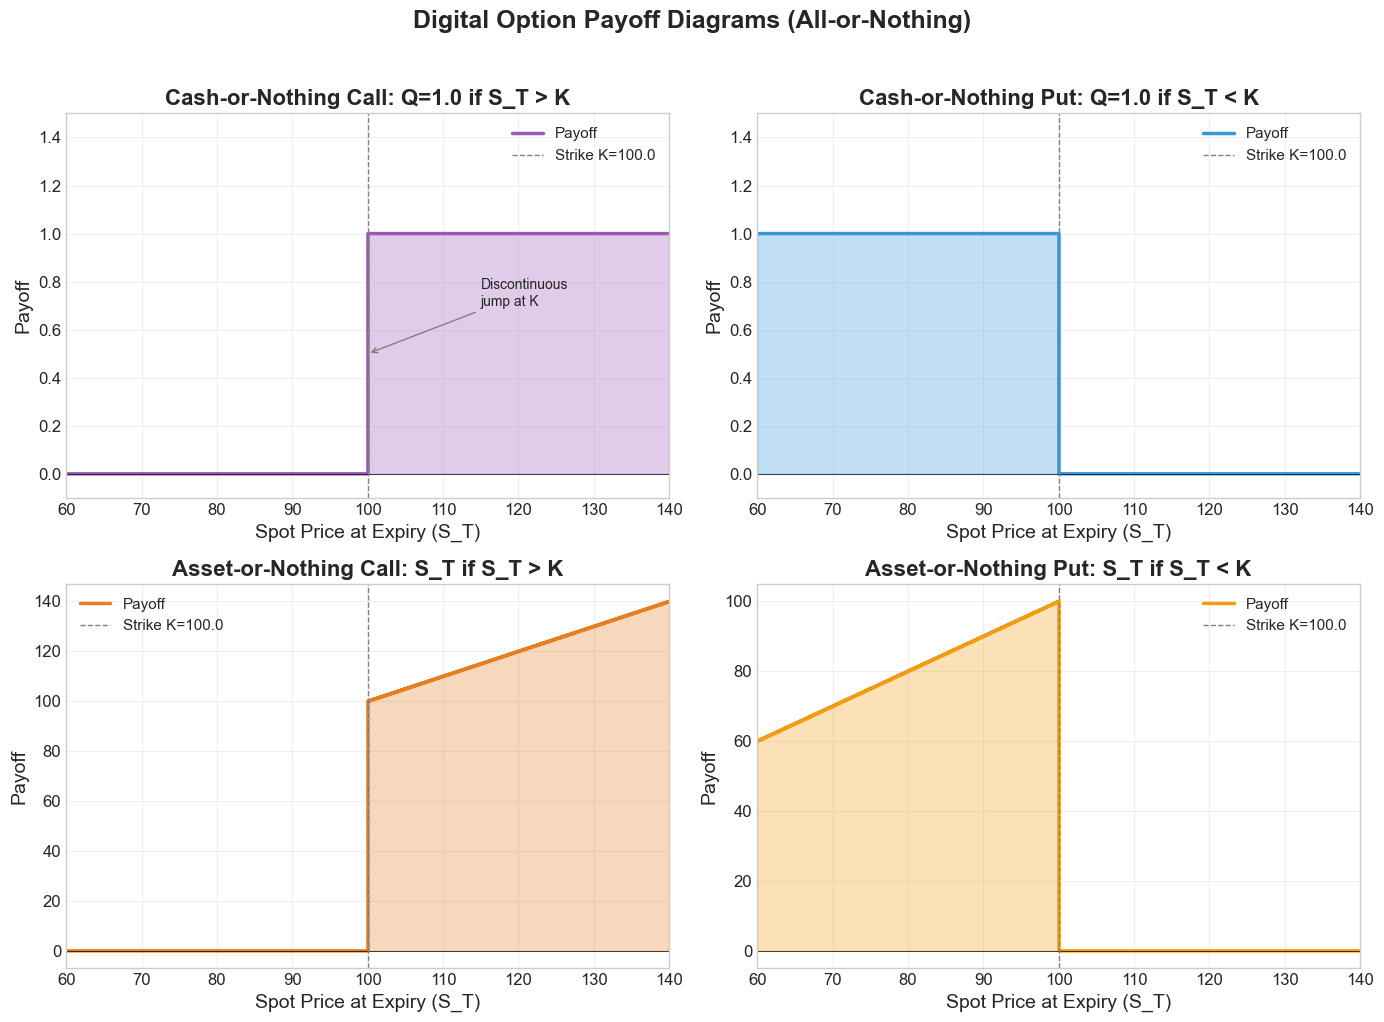

In [4]:
def plot_digital_payoff_diagrams(save_fig: bool = False):
    """
    Plot payoff diagrams for digital options.
    """
    K = BASE_PARAMS['K']
    Q = BASE_PARAMS['Q']
    spots = np.linspace(60, 140, 1000)
    
    # Payoffs (step functions)
    cash_call_payoff = np.where(spots > K, Q, 0)
    cash_put_payoff = np.where(spots < K, Q, 0)
    asset_call_payoff = np.where(spots > K, spots, 0)
    asset_put_payoff = np.where(spots < K, spots, 0)
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Cash-or-Nothing Call
    ax = axes[0, 0]
    ax.step(spots, cash_call_payoff, color=COLORS['cash'], linewidth=2.5, where='post', label='Payoff')
    ax.axhline(y=0, color='black', linewidth=0.5)
    ax.axvline(x=K, color='gray', linestyle='--', linewidth=1, label=f'Strike K={K}')
    ax.fill_between(spots, 0, cash_call_payoff, alpha=0.3, color=COLORS['cash'], step='post')
    ax.set_xlabel('Spot Price at Expiry (S_T)')
    ax.set_ylabel('Payoff')
    ax.set_title(f'Cash-or-Nothing Call: Q={Q} if S_T > K', fontweight='bold')
    ax.legend()
    ax.set_xlim(60, 140)
    ax.set_ylim(-0.1, 1.5)
    ax.grid(True, alpha=0.3)
    ax.annotate('Discontinuous\njump at K', xy=(K, 0.5), xytext=(K+15, 0.7),
                fontsize=10, arrowprops=dict(arrowstyle='->', color='gray'))
    
    # Cash-or-Nothing Put
    ax = axes[0, 1]
    ax.step(spots, cash_put_payoff, color=COLORS['put_long'], linewidth=2.5, where='post', label='Payoff')
    ax.axhline(y=0, color='black', linewidth=0.5)
    ax.axvline(x=K, color='gray', linestyle='--', linewidth=1, label=f'Strike K={K}')
    ax.fill_between(spots, 0, cash_put_payoff, alpha=0.3, color=COLORS['put_long'], step='post')
    ax.set_xlabel('Spot Price at Expiry (S_T)')
    ax.set_ylabel('Payoff')
    ax.set_title(f'Cash-or-Nothing Put: Q={Q} if S_T < K', fontweight='bold')
    ax.legend()
    ax.set_xlim(60, 140)
    ax.set_ylim(-0.1, 1.5)
    ax.grid(True, alpha=0.3)
    
    # Asset-or-Nothing Call
    ax = axes[1, 0]
    ax.step(spots, asset_call_payoff, color=COLORS['asset'], linewidth=2.5, where='post', label='Payoff')
    ax.axhline(y=0, color='black', linewidth=0.5)
    ax.axvline(x=K, color='gray', linestyle='--', linewidth=1, label=f'Strike K={K}')
    ax.fill_between(spots, 0, asset_call_payoff, alpha=0.3, color=COLORS['asset'], step='post')
    ax.set_xlabel('Spot Price at Expiry (S_T)')
    ax.set_ylabel('Payoff')
    ax.set_title('Asset-or-Nothing Call: S_T if S_T > K', fontweight='bold')
    ax.legend()
    ax.set_xlim(60, 140)
    ax.grid(True, alpha=0.3)
    
    # Asset-or-Nothing Put
    ax = axes[1, 1]
    ax.step(spots, asset_put_payoff, color=COLORS['put_short'], linewidth=2.5, where='post', label='Payoff')
    ax.axhline(y=0, color='black', linewidth=0.5)
    ax.axvline(x=K, color='gray', linestyle='--', linewidth=1, label=f'Strike K={K}')
    ax.fill_between(spots, 0, asset_put_payoff, alpha=0.3, color=COLORS['put_short'], step='post')
    ax.set_xlabel('Spot Price at Expiry (S_T)')
    ax.set_ylabel('Payoff')
    ax.set_title('Asset-or-Nothing Put: S_T if S_T < K', fontweight='bold')
    ax.legend()
    ax.set_xlim(60, 140)
    ax.grid(True, alpha=0.3)
    
    plt.suptitle('Digital Option Payoff Diagrams (All-or-Nothing)', fontsize=18, fontweight='bold', y=1.02)
    plt.tight_layout()
    if save_fig:
        plt.savefig('digital_payoff_diagrams.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_digital_payoff_diagrams(save_fig=SAVE_FIGURES)

## 3. Price Surfaces

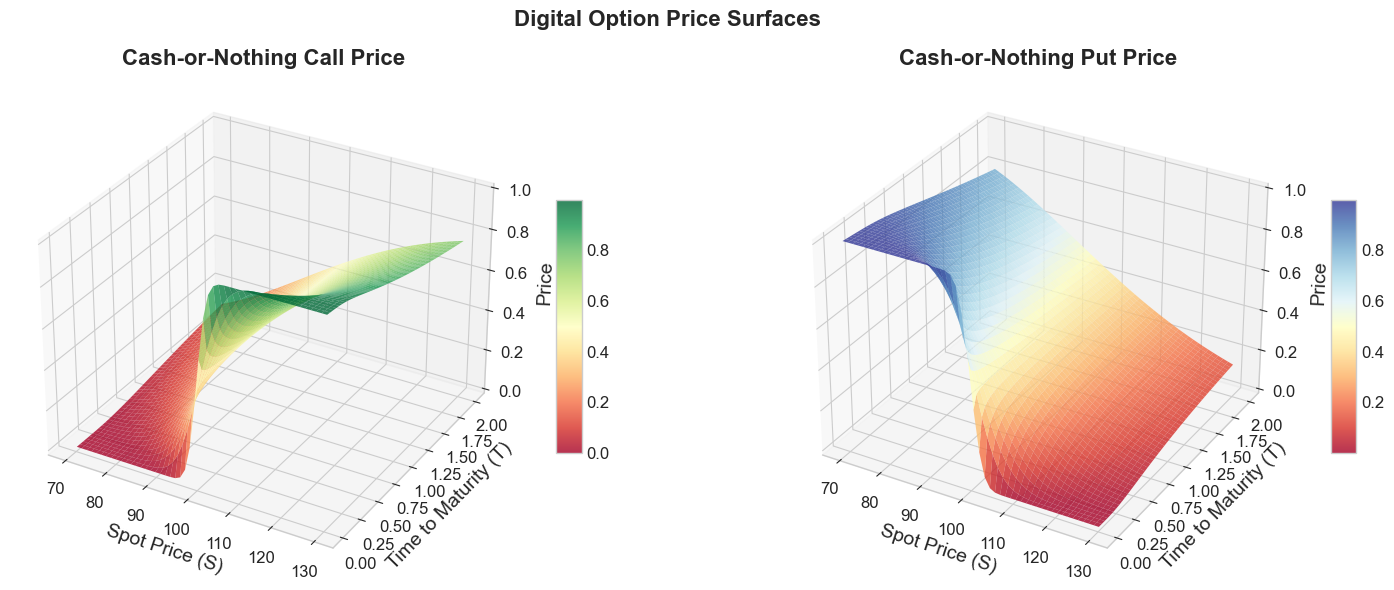

In [5]:
def plot_digital_price_surface(save_fig: bool = False):
    """
    Plot digital option price surfaces.
    """
    K = BASE_PARAMS['K']
    r = BASE_PARAMS['r']
    q = BASE_PARAMS['q']
    sigma = BASE_PARAMS['sigma']
    Q = BASE_PARAMS['Q']
    
    spots = np.linspace(70, 130, 50)
    times = np.linspace(0.01, 2.0, 50)
    S_grid, T_grid = np.meshgrid(spots, times)
    
    cash_call_prices = np.zeros_like(S_grid)
    cash_put_prices = np.zeros_like(S_grid)
    
    for i in range(len(times)):
        for j in range(len(spots)):
            cash_call_prices[i, j] = digital_cash_call(spots[j], K, times[i], r, q, sigma, Q)
            cash_put_prices[i, j] = digital_cash_put(spots[j], K, times[i], r, q, sigma, Q)
    
    fig = plt.figure(figsize=(16, 6))
    
    # Cash Call Surface
    ax1 = fig.add_subplot(121, projection='3d')
    surf1 = ax1.plot_surface(S_grid, T_grid, cash_call_prices, cmap=cm.RdYlGn, alpha=0.8)
    ax1.set_xlabel('Spot Price (S)')
    ax1.set_ylabel('Time to Maturity (T)')
    ax1.set_zlabel('Price')
    ax1.set_title('Cash-or-Nothing Call Price', fontweight='bold')
    fig.colorbar(surf1, ax=ax1, shrink=0.5, aspect=10)
    
    # Cash Put Surface
    ax2 = fig.add_subplot(122, projection='3d')
    surf2 = ax2.plot_surface(S_grid, T_grid, cash_put_prices, cmap=cm.RdYlBu, alpha=0.8)
    ax2.set_xlabel('Spot Price (S)')
    ax2.set_ylabel('Time to Maturity (T)')
    ax2.set_zlabel('Price')
    ax2.set_title('Cash-or-Nothing Put Price', fontweight='bold')
    fig.colorbar(surf2, ax=ax2, shrink=0.5, aspect=10)
    
    plt.suptitle('Digital Option Price Surfaces', fontsize=16, fontweight='bold')
    plt.tight_layout()
    if save_fig:    
        plt.savefig('digital_price_surface.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_digital_price_surface(save_fig=SAVE_FIGURES)

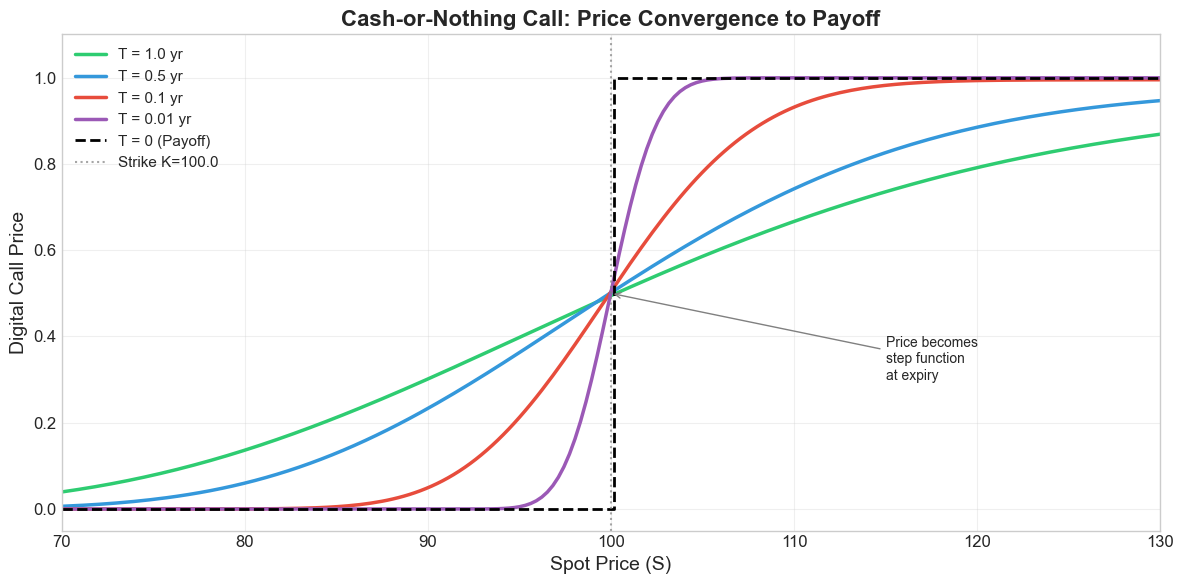

In [6]:
def plot_price_vs_spot(save_fig: bool = False):
    """
    Plot digital prices vs spot (2D) at different times to expiry.
    """
    K = BASE_PARAMS['K']
    r = BASE_PARAMS['r']
    q = BASE_PARAMS['q']
    sigma = BASE_PARAMS['sigma']
    Q = BASE_PARAMS['Q']
    
    spots = np.linspace(70, 130, 200)
    times = [1.0, 0.5, 0.1, 0.01]
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    colors = ['#2ecc71', '#3498db', '#e74c3c', '#9b59b6']
    for T, color in zip(times, colors):
        prices = [digital_cash_call(S, K, T, r, q, sigma, Q) for S in spots]
        ax.plot(spots, prices, color=color, linewidth=2.5, label=f'T = {T} yr')
    
    # Add step function (T=0)
    ax.step(spots, np.where(spots > K, Q * np.exp(-r * 0), 0), 
            color='black', linewidth=2, linestyle='--', where='post', label='T = 0 (Payoff)')
    
    ax.axvline(x=K, color='gray', linestyle=':', alpha=0.7, label=f'Strike K={K}')
    ax.set_xlabel('Spot Price (S)')
    ax.set_ylabel('Digital Call Price')
    ax.set_title('Cash-or-Nothing Call: Price Convergence to Payoff', fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xlim(70, 130)
    ax.set_ylim(-0.05, 1.1)
    
    # Add annotation
    ax.annotate('Price becomes\nstep function\nat expiry', xy=(K, 0.5), xytext=(K+15, 0.3),
                fontsize=10, arrowprops=dict(arrowstyle='->', color='gray'))
    
    plt.tight_layout()
    if save_fig:
        plt.savefig('digital_price_convergence.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_price_vs_spot(save_fig=SAVE_FIGURES)

## 4. Greeks Analysis

Digital options have unusual Greek behavior - including negative vega!

In [7]:
def digital_delta_cash_call(S, K, T, r, q, sigma, Q=1.0):
    """Delta of cash-or-nothing call."""
    if T <= 0:
        return 0.0
    d2_val = d2(S, K, T, r, q, sigma)
    return Q * np.exp(-r * T) * norm.pdf(d2_val) / (S * sigma * np.sqrt(T))

def digital_gamma_cash_call(S, K, T, r, q, sigma, Q=1.0):
    """Gamma of cash-or-nothing call."""
    if T <= 0:
        return 0.0
    d1_val = d1(S, K, T, r, q, sigma)
    d2_val = d2(S, K, T, r, q, sigma)
    return -Q * np.exp(-r * T) * norm.pdf(d2_val) * d1_val / (S**2 * sigma**2 * T)

def digital_vega_cash_call(S, K, T, r, q, sigma, Q=1.0):
    """Vega of cash-or-nothing call (can be NEGATIVE!)."""
    if T <= 0:
        return 0.0
    d1_val = d1(S, K, T, r, q, sigma)
    d2_val = d2(S, K, T, r, q, sigma)
    return -Q * np.exp(-r * T) * norm.pdf(d2_val) * d1_val / sigma

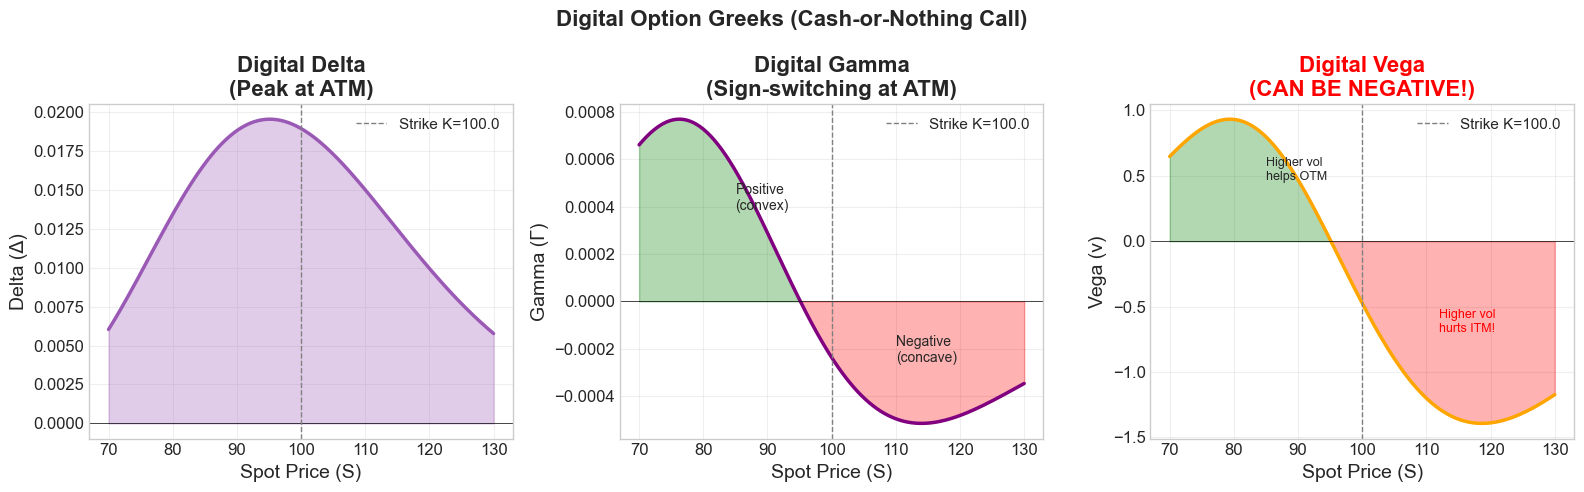

In [8]:
def plot_digital_greeks(save_fig: bool = False):
    """
    Plot Greeks for digital cash-or-nothing call.
    """
    K = BASE_PARAMS['K']
    T = BASE_PARAMS['T']
    r = BASE_PARAMS['r']
    q = BASE_PARAMS['q']
    sigma = BASE_PARAMS['sigma']
    Q = BASE_PARAMS['Q']
    
    spots = np.linspace(70, 130, 200)
    
    deltas = [digital_delta_cash_call(S, K, T, r, q, sigma, Q) for S in spots]
    gammas = [digital_gamma_cash_call(S, K, T, r, q, sigma, Q) for S in spots]
    vegas = [digital_vega_cash_call(S, K, T, r, q, sigma, Q) for S in spots]
    
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    
    # Delta
    ax = axes[0]
    ax.plot(spots, deltas, color=COLORS['cash'], linewidth=2.5)
    ax.axhline(y=0, color='black', linewidth=0.5)
    ax.axvline(x=K, color='gray', linestyle='--', linewidth=1, label=f'Strike K={K}')
    ax.fill_between(spots, 0, deltas, alpha=0.3, color=COLORS['cash'])
    ax.set_xlabel('Spot Price (S)')
    ax.set_ylabel('Delta (Δ)')
    ax.set_title('Digital Delta\n(Peak at ATM)', fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Gamma
    ax = axes[1]
    ax.plot(spots, gammas, color='purple', linewidth=2.5)
    ax.axhline(y=0, color='black', linewidth=0.5)
    ax.axvline(x=K, color='gray', linestyle='--', linewidth=1, label=f'Strike K={K}')
    ax.fill_between(spots, 0, gammas, alpha=0.3, where=np.array(gammas) > 0, color='green')
    ax.fill_between(spots, 0, gammas, alpha=0.3, where=np.array(gammas) < 0, color='red')
    ax.set_xlabel('Spot Price (S)')
    ax.set_ylabel('Gamma (Γ)')
    ax.set_title('Digital Gamma\n(Sign-switching at ATM)', fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.annotate('Positive\n(convex)', xy=(85, max(gammas)/2), fontsize=10)
    ax.annotate('Negative\n(concave)', xy=(110, min(gammas)/2), fontsize=10)
    
    # Vega (can be negative!)
    ax = axes[2]
    ax.plot(spots, vegas, color='orange', linewidth=2.5)
    ax.axhline(y=0, color='black', linewidth=0.5)
    ax.axvline(x=K, color='gray', linestyle='--', linewidth=1, label=f'Strike K={K}')
    ax.fill_between(spots, 0, vegas, alpha=0.3, where=np.array(vegas) > 0, color='green')
    ax.fill_between(spots, 0, vegas, alpha=0.3, where=np.array(vegas) < 0, color='red')
    ax.set_xlabel('Spot Price (S)')
    ax.set_ylabel('Vega (ν)')
    ax.set_title('Digital Vega\n(CAN BE NEGATIVE!)', fontweight='bold', color='red')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.annotate('Higher vol\nhelps OTM', xy=(85, max(vegas)/2), fontsize=9)
    ax.annotate('Higher vol\nhurts ITM!', xy=(112, min(vegas)/2), fontsize=9, color='red')
    
    plt.suptitle('Digital Option Greeks (Cash-or-Nothing Call)', fontsize=16, fontweight='bold')
    plt.tight_layout()
    if save_fig:
        plt.savefig('digital_greeks.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_digital_greeks(save_fig=SAVE_FIGURES)

## 5. Call Spread Approximation

A digital call can be approximated by a tight call spread.

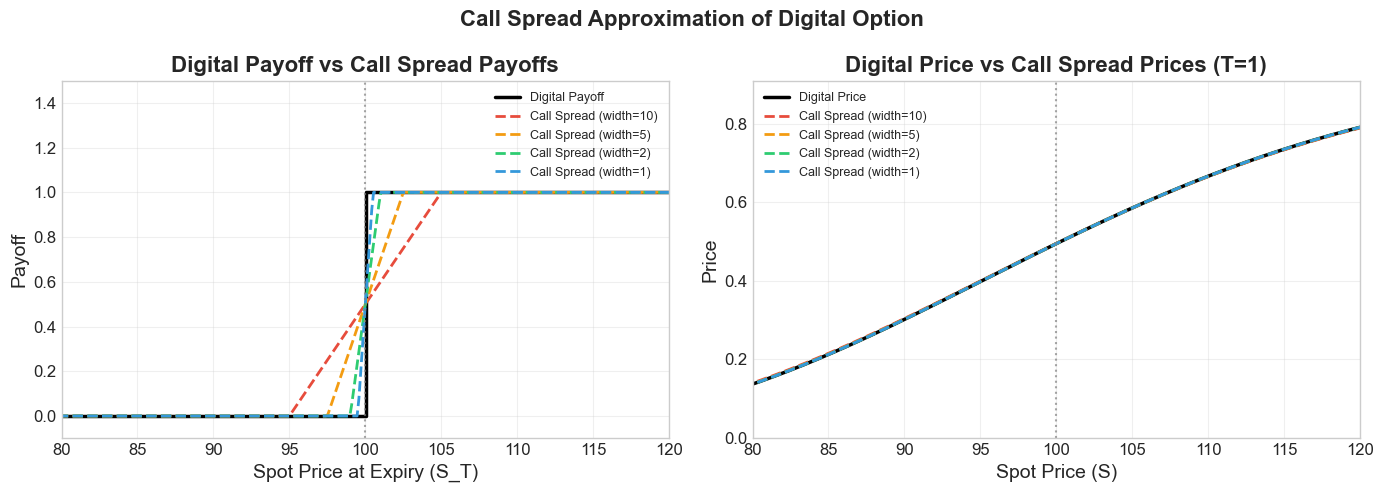

In [9]:
def plot_call_spread_approximation(save_fig: bool = False):
    """
    Show how a call spread approximates a digital option.
    """
    K = BASE_PARAMS['K']
    T = BASE_PARAMS['T']
    r = BASE_PARAMS['r']
    q = BASE_PARAMS['q']
    sigma = BASE_PARAMS['sigma']
    Q = BASE_PARAMS['Q']
    
    spots = np.linspace(70, 130, 500)
    
    # Digital price
    digital_prices = [digital_cash_call(S, K, T, r, q, sigma, Q) for S in spots]
    
    # Call spread approximations with different widths
    widths = [10, 5, 2, 1]
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Payoff comparison
    ax = axes[0]
    
    # Digital payoff
    digital_payoff = np.where(spots > K, Q, 0)
    ax.step(spots, digital_payoff, color='black', linewidth=2.5, where='post', label='Digital Payoff')
    
    # Call spread payoffs
    colors = ['#e74c3c', '#f39c12', '#2ecc71', '#3498db']
    for width, color in zip(widths, colors):
        K_low = K - width/2
        K_high = K + width/2
        # Call spread payoff: long K_low call, short K_high call
        spread_payoff = (np.maximum(spots - K_low, 0) - np.maximum(spots - K_high, 0)) / width * Q
        ax.plot(spots, spread_payoff, color=color, linewidth=2, linestyle='--', 
                label=f'Call Spread (width={width})')
    
    ax.axvline(x=K, color='gray', linestyle=':', alpha=0.7)
    ax.set_xlabel('Spot Price at Expiry (S_T)')
    ax.set_ylabel('Payoff')
    ax.set_title('Digital Payoff vs Call Spread Payoffs', fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(80, 120)
    ax.set_ylim(-0.1, 1.5)
    
    # Price comparison
    ax = axes[1]
    
    ax.plot(spots, digital_prices, color='black', linewidth=2.5, label='Digital Price')
    
    for width, color in zip(widths, colors):
        K_low = K - width/2
        K_high = K + width/2
        spread_prices = [(bs_call(S, K_low, T, r, q, sigma) - bs_call(S, K_high, T, r, q, sigma)) / width * Q 
                         for S in spots]
        ax.plot(spots, spread_prices, color=color, linewidth=2, linestyle='--', 
                label=f'Call Spread (width={width})')
    
    ax.axvline(x=K, color='gray', linestyle=':', alpha=0.7)
    ax.set_xlabel('Spot Price (S)')
    ax.set_ylabel('Price')
    ax.set_title('Digital Price vs Call Spread Prices (T=1)', fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(80, 120)
    
    plt.suptitle('Call Spread Approximation of Digital Option', fontsize=16, fontweight='bold')
    plt.tight_layout()
    if save_fig:
        plt.savefig('digital_call_spread.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_call_spread_approximation(save_fig=SAVE_FIGURES)

## 6. Digital vs Vanilla Comparison

Showing the relationship: Vanilla = Asset Digital - K × Cash Digital

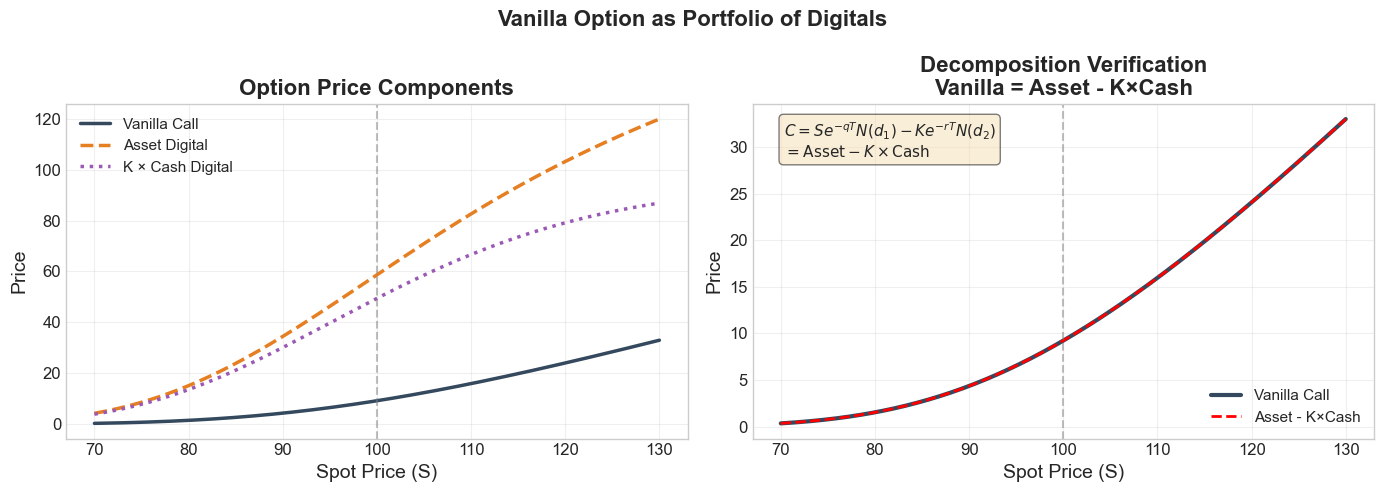

In [10]:
def plot_vanilla_decomposition(save_fig: bool = False):
    """
    Show how a vanilla option decomposes into digital options.
    """
    K = BASE_PARAMS['K']
    T = BASE_PARAMS['T']
    r = BASE_PARAMS['r']
    q = BASE_PARAMS['q']
    sigma = BASE_PARAMS['sigma']
    
    spots = np.linspace(70, 130, 200)
    
    # Prices
    vanilla_calls = [bs_call(S, K, T, r, q, sigma) for S in spots]
    asset_calls = [digital_asset_call(S, K, T, r, q, sigma) for S in spots]
    cash_calls = [digital_cash_call(S, K, T, r, q, sigma, Q=1) for S in spots]
    
    # Decomposition: Vanilla = Asset - K * Cash
    decomposition = np.array(asset_calls) - K * np.array(cash_calls)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Component prices
    ax = axes[0]
    ax.plot(spots, vanilla_calls, color=COLORS['vanilla'], linewidth=2.5, label='Vanilla Call')
    ax.plot(spots, asset_calls, color=COLORS['asset'], linewidth=2.5, linestyle='--', label='Asset Digital')
    ax.plot(spots, [K * c for c in cash_calls], color=COLORS['cash'], linewidth=2.5, 
            linestyle=':', label='K × Cash Digital')
    ax.axvline(x=K, color='gray', linestyle='--', alpha=0.5)
    ax.set_xlabel('Spot Price (S)')
    ax.set_ylabel('Price')
    ax.set_title('Option Price Components', fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Verification
    ax = axes[1]
    ax.plot(spots, vanilla_calls, color=COLORS['vanilla'], linewidth=3, label='Vanilla Call')
    ax.plot(spots, decomposition, color='red', linewidth=2, linestyle='--', 
            label='Asset - K×Cash')
    ax.axvline(x=K, color='gray', linestyle='--', alpha=0.5)
    ax.set_xlabel('Spot Price (S)')
    ax.set_ylabel('Price')
    ax.set_title('Decomposition Verification\nVanilla = Asset - K×Cash', fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Add formula annotation
    textstr = '$C = S e^{-qT}N(d_1) - K e^{-rT}N(d_2)$\n$= \\text{Asset} - K \\times \\text{Cash}$'
    ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=11,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.suptitle('Vanilla Option as Portfolio of Digitals', fontsize=16, fontweight='bold')
    plt.tight_layout()
    if save_fig:    
        plt.savefig('digital_vanilla_decomposition.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_vanilla_decomposition(save_fig=SAVE_FIGURES)

## 7. The Greeks Explosion Problem

Near expiry, digital Greeks become extreme - a major hedging challenge.

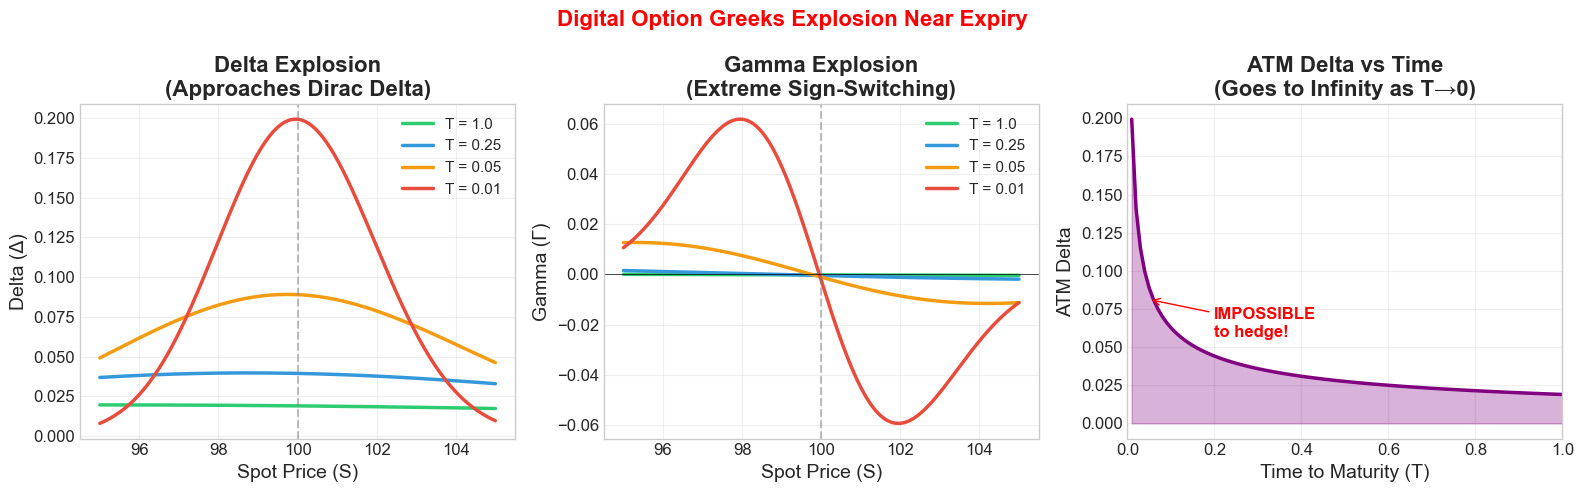

In [11]:
def plot_greeks_explosion(save_fig: bool = False):
    """
    Visualize how digital Greeks explode near expiry at ATM.
    """
    K = BASE_PARAMS['K']
    r = BASE_PARAMS['r']
    q = BASE_PARAMS['q']
    sigma = BASE_PARAMS['sigma']
    Q = BASE_PARAMS['Q']
    
    spots = np.linspace(95, 105, 200)
    times = [1.0, 0.25, 0.05, 0.01]
    
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    
    colors = ['#2ecc71', '#3498db', '#f39c12', '#e74c3c']
    
    # Delta explosion
    ax = axes[0]
    for T, color in zip(times, colors):
        deltas = [digital_delta_cash_call(S, K, T, r, q, sigma, Q) for S in spots]
        ax.plot(spots, deltas, color=color, linewidth=2.5, label=f'T = {T}')
    ax.axvline(x=K, color='gray', linestyle='--', alpha=0.5)
    ax.set_xlabel('Spot Price (S)')
    ax.set_ylabel('Delta (Δ)')
    ax.set_title('Delta Explosion\n(Approaches Dirac Delta)', fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Gamma explosion
    ax = axes[1]
    for T, color in zip(times, colors):
        gammas = [digital_gamma_cash_call(S, K, T, r, q, sigma, Q) for S in spots]
        ax.plot(spots, gammas, color=color, linewidth=2.5, label=f'T = {T}')
    ax.axvline(x=K, color='gray', linestyle='--', alpha=0.5)
    ax.axhline(y=0, color='black', linewidth=0.5)
    ax.set_xlabel('Spot Price (S)')
    ax.set_ylabel('Gamma (Γ)')
    ax.set_title('Gamma Explosion\n(Extreme Sign-Switching)', fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Delta at ATM vs time
    ax = axes[2]
    times_range = np.linspace(0.01, 1.0, 100)
    atm_deltas = [digital_delta_cash_call(K, K, T, r, q, sigma, Q) for T in times_range]
    
    ax.plot(times_range, atm_deltas, color='purple', linewidth=2.5)
    ax.fill_between(times_range, 0, atm_deltas, alpha=0.3, color='purple')
    ax.set_xlabel('Time to Maturity (T)')
    ax.set_ylabel('ATM Delta')
    ax.set_title('ATM Delta vs Time\n(Goes to Infinity as T→0)', fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, 1)
    
    # Add warning annotation
    ax.annotate('IMPOSSIBLE\nto hedge!', xy=(0.05, atm_deltas[5]), xytext=(0.2, atm_deltas[5]*0.7),
                fontsize=12, color='red', fontweight='bold',
                arrowprops=dict(arrowstyle='->', color='red'))
    
    plt.suptitle('Digital Option Greeks Explosion Near Expiry', fontsize=16, fontweight='bold', color='red')
    plt.tight_layout()
    if save_fig:
        plt.savefig('digital_greeks_explosion.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_greeks_explosion(save_fig=SAVE_FIGURES)

## Summary Statistics

In [12]:
def print_summary_statistics():
    S0 = BASE_PARAMS['S0']
    K = BASE_PARAMS['K']
    T = BASE_PARAMS['T']
    r = BASE_PARAMS['r']
    q = BASE_PARAMS['q']
    sigma = BASE_PARAMS['sigma']
    Q = BASE_PARAMS['Q']
    
    # Prices
    cash_call = digital_cash_call(S0, K, T, r, q, sigma, Q)
    cash_put = digital_cash_put(S0, K, T, r, q, sigma, Q)
    asset_call = digital_asset_call(S0, K, T, r, q, sigma)
    asset_put = digital_asset_put(S0, K, T, r, q, sigma)
    vanilla_call = bs_call(S0, K, T, r, q, sigma)
    
    # Greeks
    delta = digital_delta_cash_call(S0, K, T, r, q, sigma, Q)
    gamma = digital_gamma_cash_call(S0, K, T, r, q, sigma, Q)
    vega = digital_vega_cash_call(S0, K, T, r, q, sigma, Q)
    
    print("=" * 70)
    print("DIGITAL OPTIONS: COMPREHENSIVE SUMMARY")
    print("=" * 70)
    print(f"\nParameters: S₀={S0}, K={K}, T={T}, r={r*100:.1f}%, q={q*100:.1f}%, σ={sigma*100:.0f}%")
    
    print("\n" + "-" * 70)
    print("DIGITAL OPTION PRICES")
    print("-" * 70)
    print(f"{'Type':<25} {'Call':>15} {'Put':>15}")
    print("-" * 70)
    print(f"{'Cash-or-Nothing (Q=1)':<25} {cash_call:>15.4f} {cash_put:>15.4f}")
    print(f"{'Asset-or-Nothing':<25} {asset_call:>15.4f} {asset_put:>15.4f}")
    
    print("\n" + "-" * 70)
    print("PARITY CHECKS")
    print("-" * 70)
    print(f"Cash Call + Cash Put = {cash_call + cash_put:.4f} (should be Qe^(-rT) = {Q * np.exp(-r*T):.4f})")
    print(f"Asset Call + Asset Put = {asset_call + asset_put:.4f} (should be Se^(-qT) = {S0 * np.exp(-q*T):.4f})")
    
    print("\n" + "-" * 70)
    print("VANILLA DECOMPOSITION")
    print("-" * 70)
    decomp = asset_call - K * cash_call
    print(f"Vanilla Call = {vanilla_call:.4f}")
    print(f"Asset - K×Cash = {decomp:.4f}")
    print(f"Difference = {abs(vanilla_call - decomp):.2e}")
    
    print("\n" + "-" * 70)
    print("GREEKS (CASH-OR-NOTHING CALL, ATM)")
    print("-" * 70)
    print(f"Delta:  {delta:>10.4f}")
    print(f"Gamma:  {gamma:>10.4f}")
    print(f"Vega:   {vega:>10.4f}" + (" (NEGATIVE!)" if vega < 0 else ""))
    print("=" * 70)

print_summary_statistics()

DIGITAL OPTIONS: COMPREHENSIVE SUMMARY

Parameters: S₀=100.0, K=100.0, T=1.0, r=5.0%, q=2.0%, σ=20%

----------------------------------------------------------------------
DIGITAL OPTION PRICES
----------------------------------------------------------------------
Type                                 Call             Put
----------------------------------------------------------------------
Cash-or-Nothing (Q=1)              0.4946          0.4566
Asset-or-Nothing                  58.6851         39.3348

----------------------------------------------------------------------
PARITY CHECKS
----------------------------------------------------------------------
Cash Call + Cash Put = 0.9512 (should be Qe^(-rT) = 0.9512)
Asset Call + Asset Put = 98.0199 (should be Se^(-qT) = 98.0199)

----------------------------------------------------------------------
VANILLA DECOMPOSITION
----------------------------------------------------------------------
Vanilla Call = 9.2270
Asset - K×Cash = 9.227